<a href="https://colab.research.google.com/github/Joydas2003/Electrical-Load-Forcasting-Ml/blob/master/Machine%20Learning%20Based%20short%20term%20Electrical%20Load%20Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')
pgcb_df=pd.read_csv( "/content/drive/MyDrive/Load Forcasting/PGCB_date_power_demand.csv")
nasa_df=pd.read_csv("/content/drive/MyDrive/Load Forcasting/Hourly_Temp_Humidity (2).csv")
from IPython.display import display

display(pgcb_df)
display(nasa_df)

Mounted at /content/drive


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks
0,4/19/2015 22:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,4/19/2015 21:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,4/19/2015 19:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN
3,4/19/2015 18:30,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak
4,4/19/2015 18:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,6/17/2025 4:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN
92646,6/17/2025 3:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN
92647,6/17/2025 2:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN
92648,6/17/2025 1:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN


,datetime,Temperature_C,Humidity_%
0,2015-01-19 00:00:00,13.79,66.79
1,2015-01-19 01:00:00,13.25,69.37
2,2015-01-19 02:00:00,12.73,72.19
3,2015-01-19 03:00:00,12.21,75.48
4,2015-01-19 04:00:00,11.78,78.84
...,...,...,...
91267,2025-06-17 19:00:00,26.98,95.39
91268,2025-06-17 20:00:00,26.81,96.40
91269,2025-06-17 21:00:00,26.70,96.67
91270,2025-06-17 22:00:00,26.61,96.64


In [3]:
# Date column গুলো ensure করা datetime format এ আছে
pgcb_df['datetime'] = pd.to_datetime(pgcb_df['datetime'])
nasa_df['datetime'] = pd.to_datetime(nasa_df['datetime'])

# Merge করা, left join করলে সব PGCB date থাকবে
df = pd.merge(pgcb_df, nasa_df, on='datetime', how='left')

# Display
from IPython.display import display
display(df)

,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
0,2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
1,2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2,2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
3,2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
4,2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
92645,2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
92646,2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
92647,2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17
92648,2025-06-17 01:00:00,14093.0,14115,21,6323,1350,4019,172,0.0,28.0,924,38,1201.0,38.0,NaN,26.87,96.23


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

Convert the column datatype to datetime format.

In [5]:
df["datetime"]=pd.to_datetime(df["datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92650 entries, 0 to 92649
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   datetime                92650 non-null  datetime64[ns]
 1   generation_mw           92650 non-null  float64       
 2   demand_mw               92650 non-null  int64         
 3   load_shedding           92650 non-null  int64         
 4   gas                     92650 non-null  int64         
 5   liquid_fuel             92650 non-null  int64         
 6   coal                    92650 non-null  int64         
 7   hydro                   92650 non-null  int64         
 8   solar                   70517 non-null  float64       
 9   wind                    18676 non-null  float64       
 10  india_bheramara_hvdc    92650 non-null  int64         
 11  india_bheramara_hvdc.1  92650 non-null  int64         
 12  india_bheramara_hvdc.2  7338 non-null   float6

In [6]:
df=df.set_index("datetime")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


In [7]:
df.describe()

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,Temperature_C,Humidity_%
count,9.265000e+04,92650.000000,92650.000000,92650.000000,9.265000e+04,92650.000000,92650.000000,70517.000000,18676.000000,92650.000000,92650.000000,7338.000000,5351.000000,88469.000000,88469.000000
mean,9.429376e+03,8819.646044,81.470405,5120.782914,2.038257e+03,974.349768,96.899007,46.224101,9.233133,663.169261,93.616773,881.196375,0.546814,25.650382,78.465456
std,2.119759e+05,2772.150108,442.757182,1138.938147,9.608105e+04,1226.515481,71.442697,106.410644,16.272517,349.609395,47.483221,369.905673,4.525897,5.284393,18.188521
min,7.300000e+01,6.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.010000,17.050000
25%,6.814775e+03,6812.250000,0.000000,4419.000000,7.200000e+02,159.000000,40.000000,0.000000,0.000000,465.000000,70.000000,702.000000,0.000000,22.820000,67.980000
50%,8.412000e+03,8422.000000,0.000000,5022.000000,1.535000e+03,401.000000,79.000000,0.000000,4.000000,705.000000,97.000000,822.000000,0.000000,26.750000,83.010000
75%,1.055600e+04,10633.000000,0.000000,5812.000000,2.462000e+03,1220.000000,150.000000,25.000000,13.000000,910.000000,126.000000,1050.750000,0.000000,29.080000,94.200000
max,6.452650e+07,156050.000000,65359.000000,74818.000000,2.922290e+07,31687.000000,5623.000000,2998.000000,922.000000,76292.000000,1565.000000,12665.000000,38.000000,42.700000,100.000000


Check the missing values

In [8]:
df.isnull().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,22133
wind,73974
india_bheramara_hvdc,0


To show the records that contain any null values

In [9]:
df[df.isna().any(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


To show the records that contain all null values

In [10]:
df[df.isna().all(axis=1)]

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,


Drop those rows that contain all missing values

In [11]:
df=df.dropna(how="all")
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 22:00:00,6323.0,6323,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.48,84.04
2015-04-19 21:00:00,6667.0,6667,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,26.92,80.84
2015-04-19 19:00:00,6897.0,6897,0,4415,1836,161,41,NaN,NaN,444,0,NaN,NaN,NaN,28.49,70.64
2015-04-19 18:30:00,6933.0,6933,0,4423,1862,159,45,NaN,NaN,444,0,NaN,NaN,Evening_Peak,NaN,NaN
2015-04-19 18:00:00,6874.0,6874,0,4319,1892,155,65,NaN,NaN,443,0,NaN,NaN,NaN,29.50,65.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 04:00:00,12698.0,12698,0,6030,834,3610,172,0.0,42.0,924,38,1010.0,38.0,NaN,26.71,95.81
2025-06-17 03:00:00,13280.0,13280,0,6347,999,3698,172,0.0,40.0,924,38,1024.0,38.0,NaN,26.79,95.97
2025-06-17 02:00:00,13719.0,13719,0,6340,1196,3881,172,0.0,27.0,924,36,1105.0,38.0,NaN,26.83,96.17


Backwaer Fill -bfill

Forward Fill -ffill

In [12]:
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df

,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [13]:
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [14]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [15]:
cols = [
 'demand_mw', 'generation_mw',
 'gas', 'coal', 'hydro',
 'solar', 'wind', 'liquid_fuel',
 'india_bheramara_hvdc','Temperature_C','Humidity_%'
]
df[cols] = df[cols].interpolate(method='time')
df[cols] = df[cols].ffill().bfill()
df


,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,11896.0,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,12290.0,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,12443.0,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [16]:
df.columns

Index(['generation_mw', 'demand_mw', 'load_shedding', 'gas', 'liquid_fuel',
       'coal', 'hydro', 'solar', 'wind', 'india_bheramara_hvdc',
       'india_bheramara_hvdc.1', 'india_bheramara_hvdc.2',
       'india_bheramara_hvdc.3', 'remarks', 'Temperature_C', 'Humidity_%'],
      dtype='object')

In [17]:
df.isna().sum()

,0
generation_mw,0
demand_mw,0
load_shedding,0
gas,0
liquid_fuel,0
coal,0
hydro,0
solar,0
wind,0
india_bheramara_hvdc,0


create the quarter column in the dataset

Feature Engineering

In [18]:
df.insert(0,"hour",df.index.hour)
df.insert(2,'month',df.index.month)
df.insert(3,'year',df.index.year)
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%
datetime,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,4821.0,4,2015,4821,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.39,91.45
2015-04-19 01:00:00,1,3612.0,4,2015,3612,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,25.06,94.06
2015-04-19 02:00:00,2,3727.0,4,2015,3727,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.81,96.04
2015-04-19 03:00:00,3,3632.0,4,2015,3632,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.56,97.52
2015-04-19 04:00:00,4,3641.0,4,2015,3641,0,0,0,0,0,0.0,3.0,0,0,NaN,NaN,NaN,24.43,97.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,219.0,57.0,924,24,864.0,38.0,NaN,28.74,87.73
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,203.0,16.0,924,24,866.0,38.0,NaN,29.37,84.07
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,215.0,31.0,923,26,985.0,38.0,NaN,29.77,81.71


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 92650 entries, 2015-04-19 00:00:00 to 2025-06-17 12:00:00
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour                    92650 non-null  int32  
 1   generation_mw           92650 non-null  float64
 2   month                   92650 non-null  int32  
 3   year                    92650 non-null  int32  
 4   demand_mw               92650 non-null  int64  
 5   load_shedding           92650 non-null  int64  
 6   gas                     92650 non-null  int64  
 7   liquid_fuel             92650 non-null  int64  
 8   coal                    92650 non-null  int64  
 9   hydro                   92650 non-null  int64  
 10  solar                   92650 non-null  float64
 11  wind                    92650 non-null  float64
 12  india_bheramara_hvdc    92650 non-null  int64  
 13  india_bheramara_hvdc.1  92650 non-null  int64  
 14  ind

Laged Features : These are the past values of a time series data.

Use- past demand values are strong predictors.They can be used as input to predict future values.

In [20]:
#Demand from the same hour yesterday, same hour last week.
df['Demand_lag_24hr']=df["demand_mw"].shift(24)
df['Demand_lag_168hr']=df["demand_mw"].shift(168) #24*7=168 hour for week shift
df

,hour,generation_mw,month,year,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,...,wind,india_bheramara_hvdc,india_bheramara_hvdc.1,india_bheramara_hvdc.2,india_bheramara_hvdc.3,remarks,Temperature_C,Humidity_%,Demand_lag_24hr,Demand_lag_168hr
datetime,,,,,,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,4821.0,4,2015,4821,0,0,0,0,0,...,3.0,0,0,NaN,NaN,NaN,25.39,91.45,NaN,NaN
2015-04-19 01:00:00,1,3612.0,4,2015,3612,0,0,0,0,0,...,3.0,0,0,NaN,NaN,NaN,25.06,94.06,NaN,NaN
2015-04-19 02:00:00,2,3727.0,4,2015,3727,0,0,0,0,0,...,3.0,0,0,NaN,NaN,NaN,24.81,96.04,NaN,NaN
2015-04-19 03:00:00,3,3632.0,4,2015,3632,0,0,0,0,0,...,3.0,0,0,NaN,NaN,NaN,24.56,97.52,NaN,NaN
2015-04-19 04:00:00,4,3641.0,4,2015,3641,0,0,0,0,0,...,3.0,0,0,NaN,NaN,NaN,24.43,97.86,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,0,5678,490,3470,132,...,57.0,924,24,864.0,38.0,NaN,28.74,87.73,13155.0,12403.0
2025-06-17 09:00:00,9,12290.0,6,2025,12290,0,6065,531,3491,132,...,16.0,924,24,866.0,38.0,NaN,29.37,84.07,13569.0,12072.0
2025-06-17 10:00:00,10,12443.0,6,2025,12443,0,5900,552,3601,172,...,31.0,923,26,985.0,38.0,NaN,29.77,81.71,13816.0,11377.0


In [21]:
#Rolling Mean and rolling standard deviation
df["demand_rolling_mean_24hr"]=df["demand_mw"].rolling(window=24).mean()

In [22]:
df["demand_rolling_mean_48hr"] = df["demand_mw"].rolling(window=48).mean()

In [23]:
df["demand_ema_24hr"] = df["demand_mw"].ewm(span=24, adjust=False).mean()

In [24]:
df["temp_rolling_mean_24hr"] = df["Temperature_C"].rolling(24).mean()
df['coal_share'] = df['coal'] / df['generation_mw']
df['gas_share'] = df['gas'] / df['generation_mw']

In [25]:
df.columns

Index(['hour', 'generation_mw', 'month', 'year', 'demand_mw', 'load_shedding',
       'gas', 'liquid_fuel', 'coal', 'hydro', 'solar', 'wind',
       'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
       'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3', 'remarks',
       'Temperature_C', 'Humidity_%', 'Demand_lag_24hr', 'Demand_lag_168hr',
       'demand_rolling_mean_24hr', 'demand_rolling_mean_48hr',
       'demand_ema_24hr', 'temp_rolling_mean_24hr', 'coal_share', 'gas_share'],
      dtype='object')

In [26]:
cols_to_drop = [
     'load_shedding','liquid_fuel',
    'hydro', 'solar', 'wind',
    'india_bheramara_hvdc', 'india_bheramara_hvdc.1',
    'india_bheramara_hvdc.2', 'india_bheramara_hvdc.3',
    'remarks','liquid_fuel','hydro','solar','wind','Humidity_%'
]

df.drop(columns=cols_to_drop, inplace=True)
df


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,4821.0,4,2015,4821,0,0,25.39,NaN,NaN,NaN,NaN,4821.000000,NaN,0.000000,0.000000
2015-04-19 01:00:00,1,3612.0,4,2015,3612,0,0,25.06,NaN,NaN,NaN,NaN,4724.280000,NaN,0.000000,0.000000
2015-04-19 02:00:00,2,3727.0,4,2015,3727,0,0,24.81,NaN,NaN,NaN,NaN,4644.497600,NaN,0.000000,0.000000
2015-04-19 03:00:00,3,3632.0,4,2015,3632,0,0,24.56,NaN,NaN,NaN,NaN,4563.497792,NaN,0.000000,0.000000
2015-04-19 04:00:00,4,3641.0,4,2015,3641,0,0,24.43,NaN,NaN,NaN,NaN,4489.697969,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695,0.477303
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052,0.493491
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400,0.474162


In [27]:
df = df.loc['2015-04-19':'2025-07-18']
df

,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,,
2015-04-19 00:00:00,0,4821.0,4,2015,4821,0,0,25.39,NaN,NaN,NaN,NaN,4821.000000,NaN,0.000000,0.000000
2015-04-19 01:00:00,1,3612.0,4,2015,3612,0,0,25.06,NaN,NaN,NaN,NaN,4724.280000,NaN,0.000000,0.000000
2015-04-19 02:00:00,2,3727.0,4,2015,3727,0,0,24.81,NaN,NaN,NaN,NaN,4644.497600,NaN,0.000000,0.000000
2015-04-19 03:00:00,3,3632.0,4,2015,3632,0,0,24.56,NaN,NaN,NaN,NaN,4563.497792,NaN,0.000000,0.000000
2015-04-19 04:00:00,4,3641.0,4,2015,3641,0,0,24.43,NaN,NaN,NaN,NaN,4489.697969,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695,0.477303
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052,0.493491
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400,0.474162


In [28]:
df=df.dropna()
df

,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,5200.0,4,2015,5200,4425,171,28.73,4214.0,4821.0,5158.375000,5069.750000,5011.914316,25.811458,0.032885,0.850962
2015-04-27 09:00:00,9,5430.0,4,2015,5430,4651,163,30.01,4380.0,3612.0,5202.125000,5083.645833,5045.361171,25.805625,0.030018,0.856538
2015-04-27 10:00:00,10,5531.0,4,2015,5531,4710,161,30.87,4526.0,3727.0,5244.000000,5103.187500,5084.212277,25.862292,0.029109,0.851564
2015-04-27 11:00:00,11,5602.0,4,2015,5602,4763,150,31.46,4653.0,3632.0,5283.541667,5122.458333,5125.635295,25.960625,0.026776,0.850232
2015-04-27 12:00:00,12,5459.0,4,2015,5459,4445,148,31.77,4511.0,3641.0,5323.041667,5121.229167,5152.304471,26.088125,0.027111,0.814252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,11896,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695,0.477303
2025-06-17 09:00:00,9,12290.0,6,2025,12290,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052,0.493491
2025-06-17 10:00:00,10,12443.0,6,2025,12443,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400,0.474162


In [29]:
df['demand_mw'].describe()


,demand_mw
count,92482.000000
mean,8826.404046
std,2769.693490
min,6.000000
25%,6820.000000
50%,8430.000000
75%,10637.000000
max,156050.000000


In [30]:
df[df['demand_mw'] > 18000]


,hour,generation_mw,month,year,demand_mw,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,,
2017-05-17 12:00:00,12,7423.0,5,2017,74223,4232,161,32.040,6855.0,8583.0,9948.458333,7871.916667,12209.103412,28.462083,0.021689,0.570120
2017-08-26 15:00:00,15,8068.0,8,2017,80689,4535,138,29.320,7475.0,8559.0,11093.083333,9546.583333,13697.453849,27.808750,0.017105,0.562097
2018-12-18 08:00:00,8,5563.9,12,2018,55639,4487,149,19.590,6311.0,6627.0,8089.291667,6902.083333,9528.243767,20.091667,0.026780,0.806449
2023-02-11 18:30:00,18,10052.0,2,2023,104860,4369,1594,22.145,9531.0,6980.0,12544.166667,10457.250000,16541.156105,21.995625,0.158575,0.434640
2023-04-18 18:30:00,18,15172.0,4,2023,156050,6423,2197,30.810,15900.0,12911.0,20525.875000,17583.770833,25849.727575,30.694167,0.144806,0.423346
2023-10-04 09:00:00,9,10587.0,10,2023,20587,5234,3221,27.290,11779.0,12650.0,12126.625000,12337.250000,12227.818002,27.321250,0.304241,0.494380
2023-10-11 03:00:00,3,11468.0,10,2023,117000,6021,2965,26.300,11420.0,10439.0,16801.833333,14554.479167,21049.706911,29.248125,0.258546,0.525026
2024-04-16 07:00:00,7,11701.0,4,2024,121000,6742,2979,28.270,11250.0,11416.0,17028.958333,14411.145833,20901.542475,31.497292,0.254594,0.576190
2024-07-03 05:00:00,5,11080.0,7,2024,111140,5265,3774,26.700,11180.0,14200.0,16618.125000,14682.187500,20447.693050,28.504583,0.340614,0.475181


In [31]:

# Single-cell: Replace outliers

# Calculate IQR (optional for analysis)
Q1 = df['demand_mw'].quantile(0.25)
Q3 = df['demand_mw'].quantile(0.75)
IQR = Q3 - Q1

# Replace extreme values without deleting rows
df['demand_mw'] = df['demand_mw'].clip(lower=3500, upper=18000)

/tmp/ipykernel_1532/165475106.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['demand_mw'] = df['demand_mw'].clip(lower=3500, upper=18000)


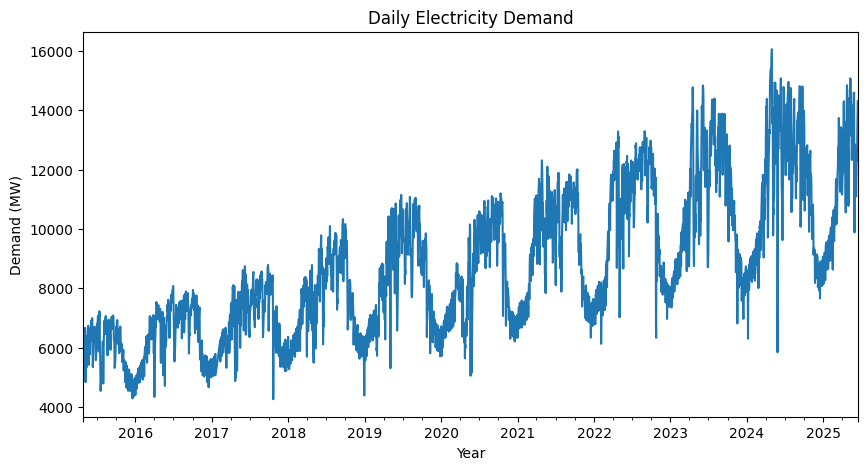

In [32]:
# Daily average demand
df_daily = df['demand_mw'].resample('D').mean().interpolate()

df_daily.plot(figsize=(10,5), title="Daily Electricity Demand")
plt.xlabel("Year")
plt.ylabel("Demand (MW)")
plt.show()


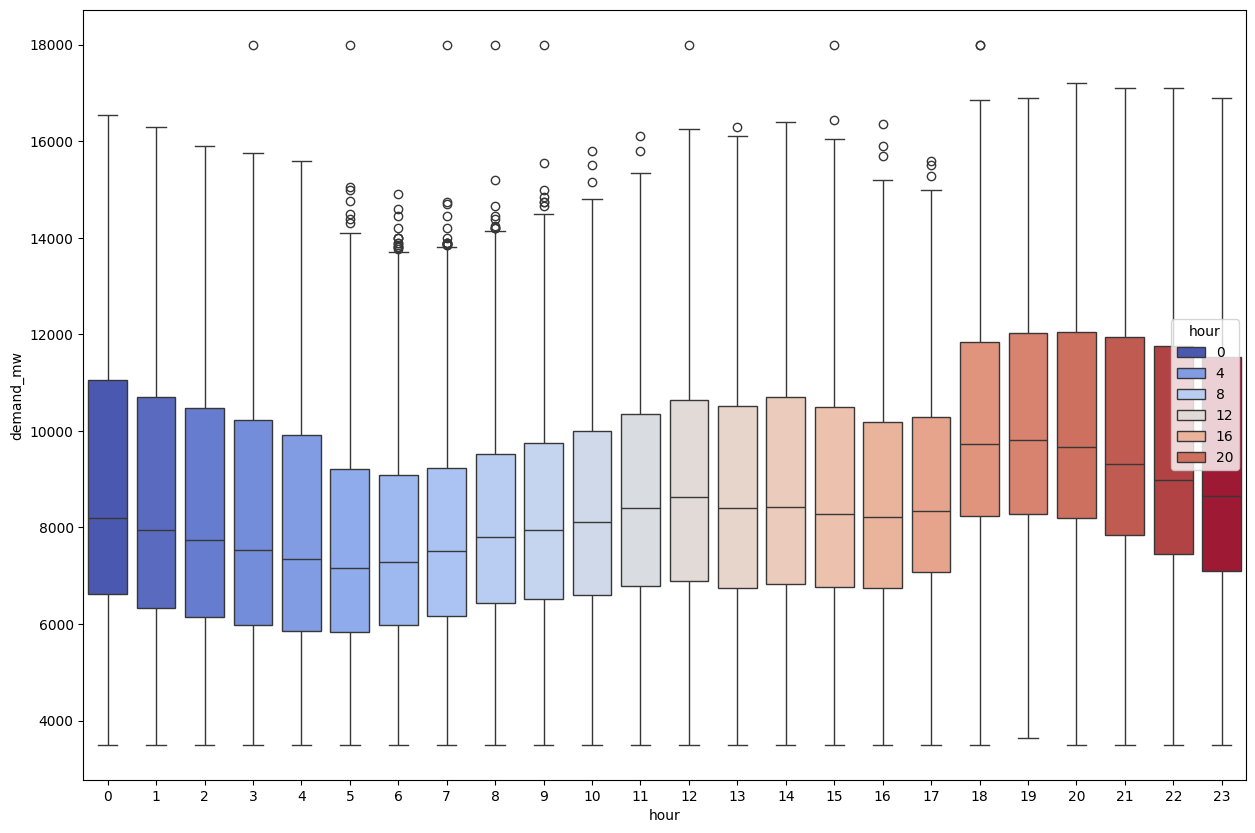

In [33]:
plt.figure(figsize=(15,10))
sns.boxplot(
    x="hour",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="hour",
    #showfliers=False
);


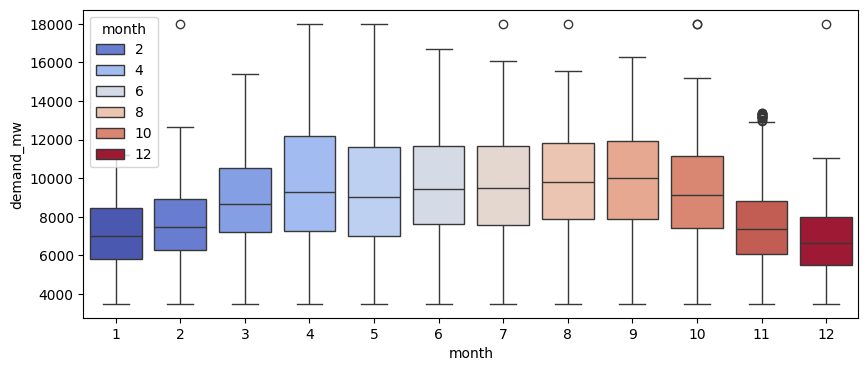

In [34]:
plt.figure(figsize=(10,4))
sns.boxplot(
    x="month",
    y="demand_mw",
    data=df,
    palette="coolwarm",
    hue="month",
    #showfliers=False
);


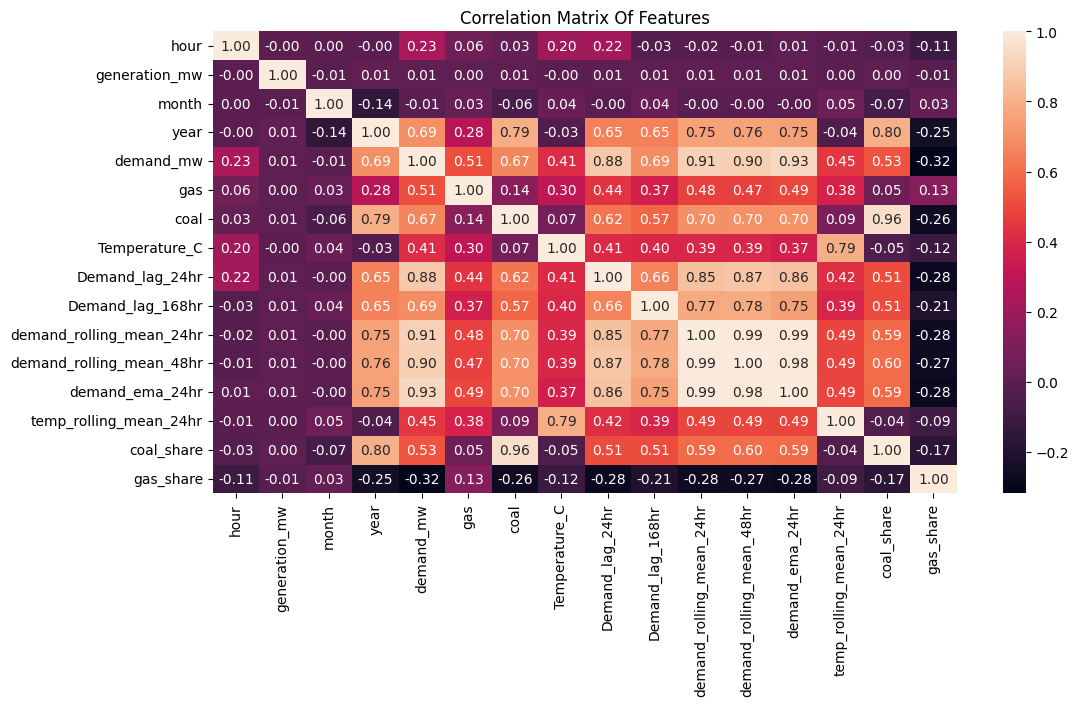

In [35]:
# correlation matrix
plt.figure(figsize=(12,6))
plt.title("Correlation Matrix Of Features")
sns.heatmap(df.corr(),annot=True,fmt=".2f");

In [36]:
#define target variable y
y=df.demand_mw # target variable/ dependent variable
print(y)

datetime
2015-04-27 08:00:00     5200
2015-04-27 09:00:00     5430
2015-04-27 10:00:00     5531
2015-04-27 11:00:00     5602
2015-04-27 12:00:00     5459
                       ...  
2025-06-17 08:00:00    11896
2025-06-17 09:00:00    12290
2025-06-17 10:00:00    12443
2025-06-17 11:00:00    12826
2025-06-17 12:00:00    13139
Name: demand_mw, Length: 92482, dtype: int64


In [37]:
#define Features(x)
x=df.drop("demand_mw",axis=1)  #indipendent variables/ features/predictors
x

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,5200.0,4,2015,4425,171,28.73,4214.0,4821.0,5158.375000,5069.750000,5011.914316,25.811458,0.032885,0.850962
2015-04-27 09:00:00,9,5430.0,4,2015,4651,163,30.01,4380.0,3612.0,5202.125000,5083.645833,5045.361171,25.805625,0.030018,0.856538
2015-04-27 10:00:00,10,5531.0,4,2015,4710,161,30.87,4526.0,3727.0,5244.000000,5103.187500,5084.212277,25.862292,0.029109,0.851564
2015-04-27 11:00:00,11,5602.0,4,2015,4763,150,31.46,4653.0,3632.0,5283.541667,5122.458333,5125.635295,25.960625,0.026776,0.850232
2015-04-27 12:00:00,12,5459.0,4,2015,4445,148,31.77,4511.0,3641.0,5323.041667,5121.229167,5152.304471,26.088125,0.027111,0.814252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695,0.477303
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052,0.493491
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400,0.474162


In [38]:
# Splitting the data into training and teating data
x_train=x.loc[ : "2023-12-31"]   #taking 80% 0f data as training data
x_train

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,
2015-04-27 08:00:00,8,5200.0,4,2015,4425,171,28.73,4214.0,4821.0,5158.375000,5069.750000,5011.914316,25.811458,0.032885,0.850962
2015-04-27 09:00:00,9,5430.0,4,2015,4651,163,30.01,4380.0,3612.0,5202.125000,5083.645833,5045.361171,25.805625,0.030018,0.856538
2015-04-27 10:00:00,10,5531.0,4,2015,4710,161,30.87,4526.0,3727.0,5244.000000,5103.187500,5084.212277,25.862292,0.029109,0.851564
2015-04-27 11:00:00,11,5602.0,4,2015,4763,150,31.46,4653.0,3632.0,5283.541667,5122.458333,5125.635295,25.960625,0.026776,0.850232
2015-04-27 12:00:00,12,5459.0,4,2015,4445,148,31.77,4511.0,3641.0,5323.041667,5121.229167,5152.304471,26.088125,0.027111,0.814252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-31 19:00:00,19,9894.0,12,2023,4127,3467,17.86,9993.0,7288.0,8576.541667,8395.895833,8945.023434,18.699792,0.350414,0.417121
2023-12-31 20:00:00,20,9669.0,12,2023,4050,3471,17.15,9706.0,6975.0,8575.000000,8418.541667,9002.941559,18.608125,0.358982,0.418864
2023-12-31 21:00:00,21,9250.0,12,2023,3954,3355,16.60,8625.0,6844.0,8601.041667,8443.750000,9022.706234,18.563542,0.362703,0.427459


In [39]:
y_train=y.loc[ : "2023-12-31"]   #taking 80% 0f data as training data
y_train

,demand_mw
datetime,
2015-04-27 08:00:00,5200
2015-04-27 09:00:00,5430
2015-04-27 10:00:00,5531
2015-04-27 11:00:00,5602
2015-04-27 12:00:00,5459
...,...
2023-12-31 19:00:00,9894
2023-12-31 20:00:00,9669
2023-12-31 21:00:00,9250


In [40]:
y_test=y.loc[ "2024-01-01": ]   #taking 20% 0f data as testing data
y_test

,demand_mw
datetime,
2024-01-01 00:00:00,7580
2024-01-01 01:00:00,7259
2024-01-01 02:00:00,7010
2024-01-01 03:00:00,6733
2024-01-01 04:00:00,6598
...,...
2025-06-17 08:00:00,11896
2025-06-17 09:00:00,12290
2025-06-17 10:00:00,12443


In [41]:
x_test=x.loc[ "2024-01-01": ]   #taking 20% 0f data as testing data
x_test

,hour,generation_mw,month,year,gas,coal,Temperature_C,Demand_lag_24hr,Demand_lag_168hr,demand_rolling_mean_24hr,demand_rolling_mean_48hr,demand_ema_24hr,temp_rolling_mean_24hr,coal_share,gas_share
datetime,,,,,,,,,,,,,,,
2024-01-01 00:00:00,0,7580.0,1,2024,3936,2887,15.27,7385.0,7313.0,8649.166667,8498.187500,8812.360752,18.504375,0.380871,0.519261
2024-01-01 01:00:00,1,7259.0,1,2024,3781,2720,14.84,7123.0,7982.0,8654.833333,8511.062500,8688.091892,18.499375,0.374707,0.520871
2024-01-01 02:00:00,2,7010.0,1,2024,3659,2595,14.44,6791.0,8527.0,8663.958333,8523.062500,8553.844541,18.496042,0.370185,0.521969
2024-01-01 03:00:00,3,6733.0,1,2024,3421,2566,14.03,6752.0,8375.0,8663.166667,8532.479167,8408.176977,18.489375,0.381108,0.508094
2024-01-01 04:00:00,4,6598.0,1,2024,3304,2535,13.62,7068.0,8536.0,8643.583333,8531.250000,8263.362819,18.478125,0.384207,0.500758
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-17 08:00:00,8,11896.0,6,2025,5678,3470,28.74,13155.0,12403.0,13804.000000,14023.041667,13479.928197,28.260000,0.291695,0.477303
2025-06-17 09:00:00,9,12290.0,6,2025,6065,3491,29.37,13569.0,12072.0,13750.708333,13984.437500,13384.733941,28.239583,0.284052,0.493491
2025-06-17 10:00:00,10,12443.0,6,2025,5900,3601,29.77,13816.0,11377.0,13693.500000,13950.562500,13309.395226,28.220417,0.289400,0.474162


In [42]:
print(x_train.shape)
print(y_train.shape)

(79146, 15)
(79146,)


In [43]:
print(x_test.shape)
print(y_test.shape)

(13336, 15)
(13336,)


#Decision Tree

In [44]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
dt_model=DecisionTreeRegressor(max_depth=6,
                               min_samples_split=20,
                               min_samples_leaf=10,
                               criterion="squared_error",
                               random_state=42)
dt_model.fit(x_train,y_train)
dt_pred=dt_model.predict(x_test)
rmse_dt=np.sqrt(mean_squared_error(y_test,dt_pred))
mae_dt=mean_absolute_error(y_test,dt_pred)

print("Decision Tree RMSE: ",rmse_dt)
print("Decision Tree MAE ",mae_dt)

Decision Tree RMSE:  523.6276011487134
Decision Tree MAE  288.0099287086244


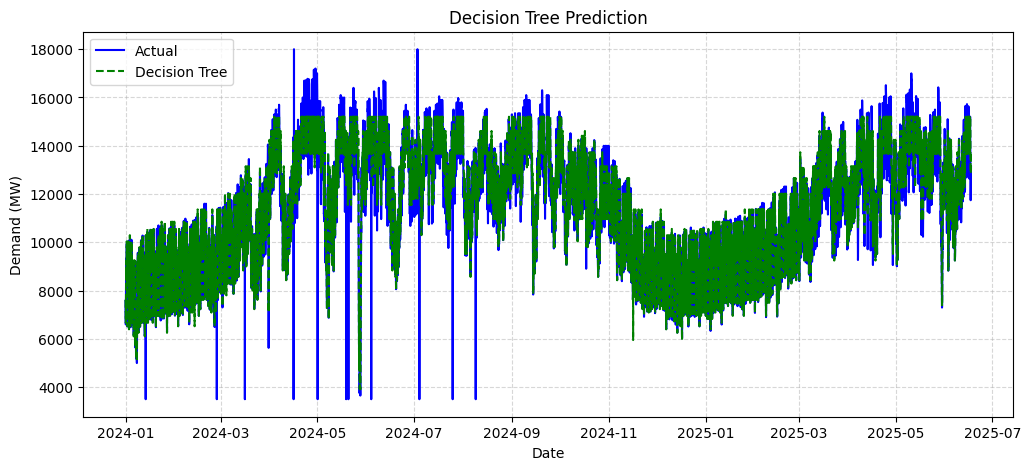

In [45]:
# Decision Tree prediction plot
plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')           # Real demand
plt.plot(y_test.index, dt_pred, label='Decision Tree', color='green', linestyle='--')  # Predicted by Decision Tree
plt.title("Decision Tree Prediction")
plt.xlabel("Date")
plt.ylabel("Demand (MW)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


#Random Forest

In [46]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
rf_model=RandomForestRegressor(n_estimators=200,
                               max_depth=8,
                               min_samples_split=5,
                               min_samples_leaf=2,
                               random_state=42)
rf_model.fit(x_train, y_train)

rf_pred = rf_model.predict(x_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mae_rf = mean_absolute_error(y_test, rf_pred)
print("Random Forest RMSE:", rmse_rf)
print("Random Forest MAE:", mae_rf)

Random Forest RMSE: 446.5990521502054
Random Forest MAE: 234.7734889749398


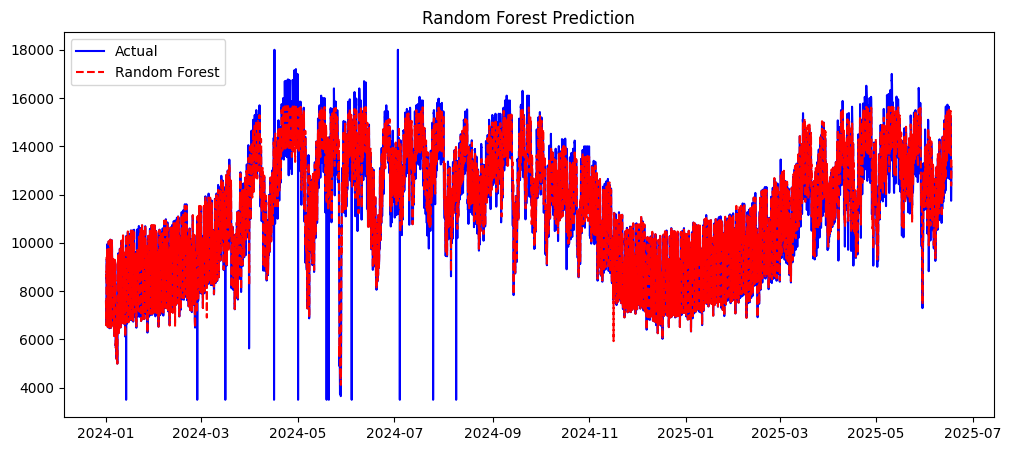

In [47]:

plt.figure(figsize=(12,5))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, rf_pred, label='Random Forest', color='red', linestyle='--')
plt.title("Random Forest Prediction")
plt.legend()
plt.show()


#XGBoost

In [48]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit

In [49]:
model_xgb=XGBRegressor(n_estimators=2500,
                       early_stopping_rounds=50,
                       learning_rate=0.005,
                       max_depth=7,
                       min_child_weight=3,
                       gamma=1,
                       subsample=0.8,
                       reg_alpha=0.1,
                       reg_lambda=1.5,
                       random_state=42,
                       objective="reg:squarederror")

In [50]:
model_xgb.fit(x_train,y_train,eval_set=[(x_train,y_train),(x_test,y_test)],verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.005, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2500,
             n_jobs=None, num_parallel_tree=None, ...)

In [51]:
predictions_xgb=model_xgb.predict(x_test)
rmse_xgb=np.sqrt(mean_squared_error(y_test,predictions_xgb))
mae_xgb=mean_absolute_error(y_test,predictions_xgb)
print("XGBoost RMSE:",rmse_xgb)
print("XGBoost MAE:",mae_xgb)

XGBoost RMSE: 464.628262027828
XGBoost MAE: 243.00645446777344


Text(65.72222222222221, 0.5, 'Demand')

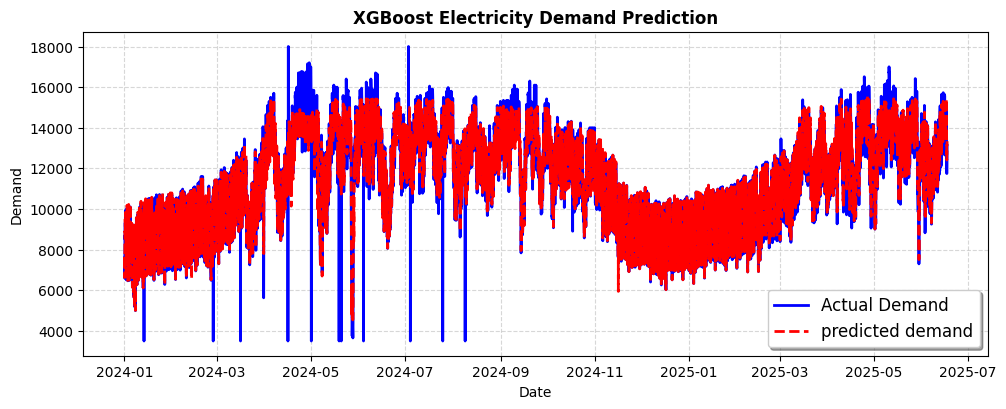

In [52]:
plt.figure(figsize=(10,4))
plt.plot(y_test.index,y_test,label="Actual Demand",color="Blue", linewidth=2)
plt.plot(y_test.index,predictions_xgb,label="predicted demand",color='Red',linestyle="--", linewidth=2)
plt.title("XGBoost Electricity Demand Prediction",fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

In [53]:
from sklearn.metrics import r2_score
r2_dt=r2_score(y_test,dt_pred)
r2_rf=r2_score(y_test,rf_pred)
r2_xgb=r2_score(y_test,predictions_xgb)

print("Decision Tree R2: ",r2_dt)
print("Random Forest R2:",r2_rf)
print("XGBoost R2: ",r2_xgb)




Decision Tree R2:  0.9510371578710644
Random Forest R2: 0.9643830151381868
XGBoost R2:  0.9614492654800415


ANN

Scaling (MinMax)

In [54]:
from sklearn.preprocessing import MinMaxScaler

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
x_test_scaled = scaler_x.transform(x_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1,1))

Tensor Convert

In [55]:
import torch

x_train_t = torch.tensor(x_train_scaled, dtype=torch.float32)
x_test_t = torch.tensor(x_test_scaled, dtype=torch.float32)

y_train_t = torch.tensor(y_train_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test_scaled, dtype=torch.float32)

In [56]:
import torch.nn as nn
import torch.optim as optim

class ResearchANN(nn.Module):
    def __init__(self, input_size):
        super(ResearchANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.model(x)

Initialize Model

In [57]:
input_size = x_train_t.shape[1]

model = ResearchANN(input_size)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

Training with Loss Tracking

In [58]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model.train()

    outputs = model(x_train_t)
    loss = criterion(outputs, y_train_t)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    if (epoch+1) % 25 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {loss.item():.6f}")

Epoch [25/50] Loss: 0.018597
Epoch [50/50] Loss: 0.010848


Evaluation  (RMSE + MAE + MAPE + R²)

In [59]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

model.eval()

with torch.no_grad():
    predictions = model(x_test_t)

# Back to original scale
predictions = scaler_y.inverse_transform(predictions.numpy())
y_test_actual = scaler_y.inverse_transform(y_test_t.numpy())

# Metrics
rmse_ann = np.sqrt(mean_squared_error(y_test_actual, predictions))
mae_ann = mean_absolute_error(y_test_actual, predictions)

# MAPE (manual calculation)
mape_ann = np.mean(np.abs((y_test_actual - predictions) / y_test_actual)) * 100

r2_ann = r2_score(y_test_actual, predictions)

print("Research ANN RMSE:", rmse_ann)
print("Research ANN MAE:", mae_ann)
print("Research ANN MAPE:", mape_ann)
print("Research ANN R2:", r2_ann)

Research ANN RMSE: 1588.4386988486524
Research ANN MAE: 1305.3800048828125
Research ANN MAPE: 11.1693735
Research ANN R2: 0.5494297742843628


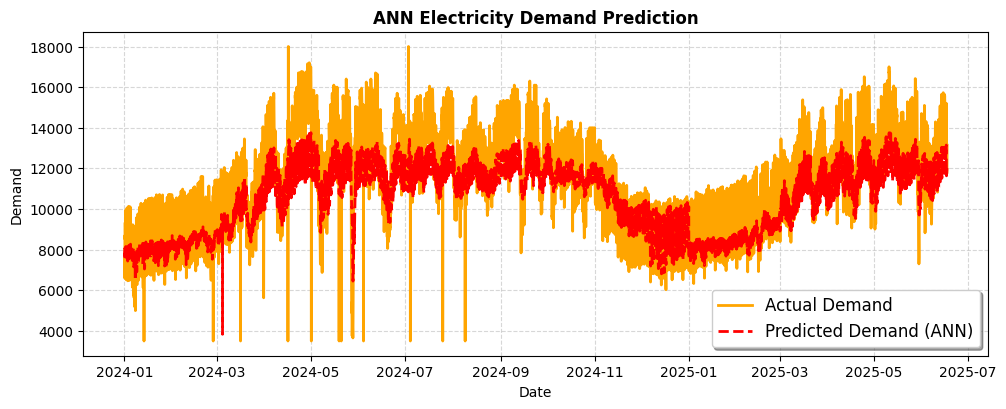

In [60]:
plt.figure(figsize=(10,4))

plt.plot(y_test.index, y_test_actual.flatten(),
         label="Actual Demand",
         color="Orange",
         linewidth=2)

plt.plot(y_test.index, predictions.flatten(),
         label="Predicted Demand (ANN)",
         color="Red",
         linestyle="--",
         linewidth=2)

plt.title("ANN Electricity Demand Prediction", fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.legend(fontsize=12, shadow=True)

plt.xlabel("Date")
plt.ylabel("Demand")

plt.show()